In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# Keeping the random seeds fixed so the results stay more reproducible
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Loading the tabular dataset from the student wellness dataset
tabular_base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/tabular"

train_tabular_path = os.path.join(tabular_base_path, "train.csv")
test_tabular_path = os.path.join(tabular_base_path, "test.csv")

train_tabular_df = pd.read_csv(train_tabular_path)
test_tabular_df = pd.read_csv(test_tabular_path)

print("Train tabular shape:", train_tabular_df.shape)
print("Test tabular shape:", test_tabular_df.shape)
train_tabular_df.head()

Train tabular shape: (240, 13)
Test tabular shape: (80, 13)


,sample_id,sleep_hours,study_hours,attendance_pct,stress_score,caffeine_cups,exercise_minutes,screen_time_hours,assignment_delay_days,social_minutes,mood_score,label,label_id
0,train_0000,8.18,1.46,96.50,29.41,0.00,31.98,4.65,0.18,59.80,7.15,low_risk,0
1,train_0001,7.33,4.78,85.40,56.27,2.13,21.41,6.44,0.54,55.54,6.25,moderate_risk,1
2,train_0002,5.49,4.82,84.34,68.45,2.50,14.48,8.14,3.57,34.95,4.93,high_risk,2
3,train_0003,5.88,6.09,64.93,79.86,4.23,19.29,8.86,4.16,5.11,3.65,critical_risk,3
4,train_0004,8.45,3.04,88.01,22.32,1.08,47.19,5.55,0.72,68.15,8.07,low_risk,0


In [4]:
# Looking at the column names and label distribution
print("Columns:")
print(train_tabular_df.columns)

print("\nLabel counts:")
print(train_tabular_df["label"].value_counts())

Columns:
Index(['sample_id', 'sleep_hours', 'study_hours', 'attendance_pct',
       'stress_score', 'caffeine_cups', 'exercise_minutes',
       'screen_time_hours', 'assignment_delay_days', 'social_minutes',
       'mood_score', 'label', 'label_id'],
      dtype='object')

Label counts:
label
low_risk         60
moderate_risk    60
high_risk        60
critical_risk    60
Name: count, dtype: int64


In [5]:
# Converting the text labels into numeric classes
label_to_index = {
    label: idx for idx, label in enumerate(sorted(train_tabular_df["label"].unique()))
}

index_to_label = {idx: label for label, idx in label_to_index.items()}

train_tabular_df["label_id"] = train_tabular_df["label"].map(label_to_index)
test_tabular_df["label_id"] = test_tabular_df["label"].map(label_to_index)

print(label_to_index)

{'critical_risk': 0, 'high_risk': 1, 'low_risk': 2, 'moderate_risk': 3}


In [8]:
# Keeping only numeric feature columns and removing label/id-style columns
excluded_columns = ["label", "label_id"]

numeric_feature_columns = [
    col for col in train_tabular_df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(train_tabular_df[col])
]

print("Numeric feature columns:")
print(numeric_feature_columns)

X_tab_train = train_tabular_df[numeric_feature_columns].values
y_tab_train = train_tabular_df["label_id"].values

X_tab_test = test_tabular_df[numeric_feature_columns].values
y_tab_test = test_tabular_df["label_id"].values

X_tab_train, X_tab_val, y_tab_train, y_tab_val = train_test_split(
    X_tab_train,
    y_tab_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_tab_train
)

print("Train shape:", X_tab_train.shape)
print("Validation shape:", X_tab_val.shape)
print("Test shape:", X_tab_test.shape)

Numeric feature columns:
['sleep_hours', 'study_hours', 'attendance_pct', 'stress_score', 'caffeine_cups', 'exercise_minutes', 'screen_time_hours', 'assignment_delay_days', 'social_minutes', 'mood_score']
Train shape: (192, 10)
Validation shape: (48, 10)
Test shape: (80, 10)


In [9]:
# Scaling the tabular features so training becomes more stable
scaler = StandardScaler()

X_tab_train = scaler.fit_transform(X_tab_train)
X_tab_val = scaler.transform(X_tab_val)
X_tab_test = scaler.transform(X_tab_test)

In [10]:
# This is a simple tabular classifier that I will use for the A/B tests
def build_tabular_model(input_dim, dropout_rate=0.2):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu"),
        layers.Dense(len(label_to_index), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [11]:
# Training a baseline tabular model without augmentation
tabular_baseline_model = build_tabular_model(X_tab_train.shape[1])

history_tabular_baseline = tabular_baseline_model.fit(
    X_tab_train,
    y_tab_train,
    validation_data=(X_tab_val, y_tab_val),
    epochs=20,
    batch_size=16,
    verbose=0
)

tab_baseline_test_loss, tab_baseline_test_acc = tabular_baseline_model.evaluate(
    X_tab_test,
    y_tab_test,
    verbose=0
)

print("Tabular Baseline Test Accuracy:", round(tab_baseline_test_acc, 4))

Tabular Baseline Test Accuracy: 0.925


In [12]:
# A simple tabular augmentation idea: adding a little Gaussian noise to numeric features
def augment_tabular_data(X, noise_std=0.08):
    noisy_copy = X + np.random.normal(0, noise_std, X.shape)
    return noisy_copy

In [13]:
# Creating augmented tabular samples and combining them with the original training set
X_tab_train_aug = augment_tabular_data(X_tab_train, noise_std=0.08)
y_tab_train_aug = y_tab_train.copy()

X_tab_train_combined = np.vstack([X_tab_train, X_tab_train_aug])
y_tab_train_combined = np.concatenate([y_tab_train, y_tab_train_aug])

print("Original train size:", len(X_tab_train))
print("Combined augmented train size:", len(X_tab_train_combined))

Original train size: 192
Combined augmented train size: 384


In [14]:
# Training the tabular model with augmented data
tabular_aug_model = build_tabular_model(X_tab_train.shape[1])

history_tabular_aug = tabular_aug_model.fit(
    X_tab_train_combined,
    y_tab_train_combined,
    validation_data=(X_tab_val, y_tab_val),
    epochs=20,
    batch_size=16,
    verbose=0
)

tab_aug_test_loss, tab_aug_test_acc = tabular_aug_model.evaluate(
    X_tab_test,
    y_tab_test,
    verbose=0
)

print("Tabular Augmentation Test Accuracy:", round(tab_aug_test_acc, 4))

Tabular Augmentation Test Accuracy: 0.9625


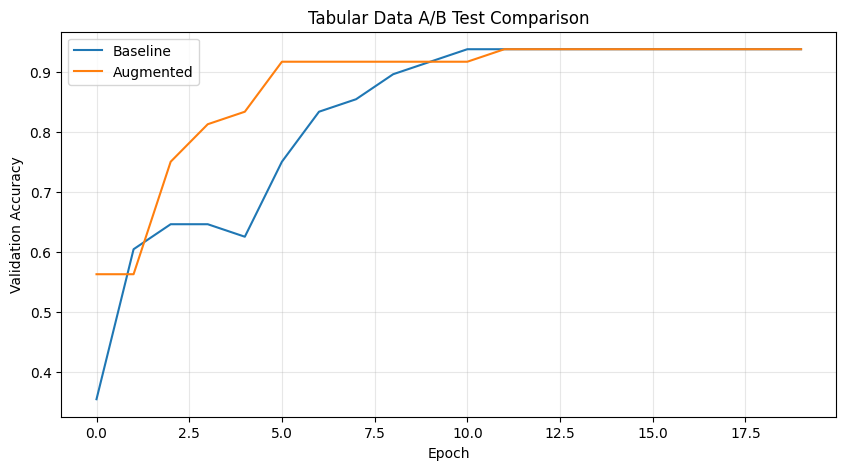

In [15]:
# Comparing baseline vs augmented training for tabular data
plt.figure(figsize=(10, 5))
plt.plot(history_tabular_baseline.history["val_accuracy"], label="Baseline")
plt.plot(history_tabular_aug.history["val_accuracy"], label="Augmented")
plt.title("Tabular Data A/B Test Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
import os

timeseries_base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/timeseries"
print(os.listdir(timeseries_base_path))

['train_timeseries.npy', 'test_timeseries.npy', 'test_labels.csv', 'train_labels.csv']


In [18]:
# Loading the time series dataset
timeseries_base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/timeseries"

train_timeseries_path = os.path.join(timeseries_base_path, "train_timeseries.npy")
test_timeseries_path = os.path.join(timeseries_base_path, "test_timeseries.npy")
train_labels_path = os.path.join(timeseries_base_path, "train_labels.csv")
test_labels_path = os.path.join(timeseries_base_path, "test_labels.csv")

X_ts_train_full = np.load(train_timeseries_path)
X_ts_test = np.load(test_timeseries_path)

train_labels_df = pd.read_csv(train_labels_path)
test_labels_df = pd.read_csv(test_labels_path)

y_ts_train_full = train_labels_df["label"].map(label_to_index).values
y_ts_test = test_labels_df["label"].map(label_to_index).values

print("Train timeseries shape:", X_ts_train_full.shape)
print("Test timeseries shape:", X_ts_test.shape)
print("Train labels shape:", y_ts_train_full.shape)
print("Test labels shape:", y_ts_test.shape)

train_labels_df.head()

Train timeseries shape: (240, 30, 4)
Test timeseries shape: (80, 30, 4)
Train labels shape: (240,)
Test labels shape: (80,)


,sample_id,label,label_id
0,train_0000,low_risk,0
1,train_0001,moderate_risk,1
2,train_0002,high_risk,2
3,train_0003,critical_risk,3
4,train_0004,low_risk,0


In [19]:
# Making a validation split for the time series training data
X_ts_train, X_ts_val, y_ts_train, y_ts_val = train_test_split(
    X_ts_train_full,
    y_ts_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_ts_train_full
)

print("Train timeseries split:", X_ts_train.shape)
print("Validation timeseries split:", X_ts_val.shape)
print("Test timeseries split:", X_ts_test.shape)

Train timeseries split: (192, 30, 4)
Validation timeseries split: (48, 30, 4)
Test timeseries split: (80, 30, 4)


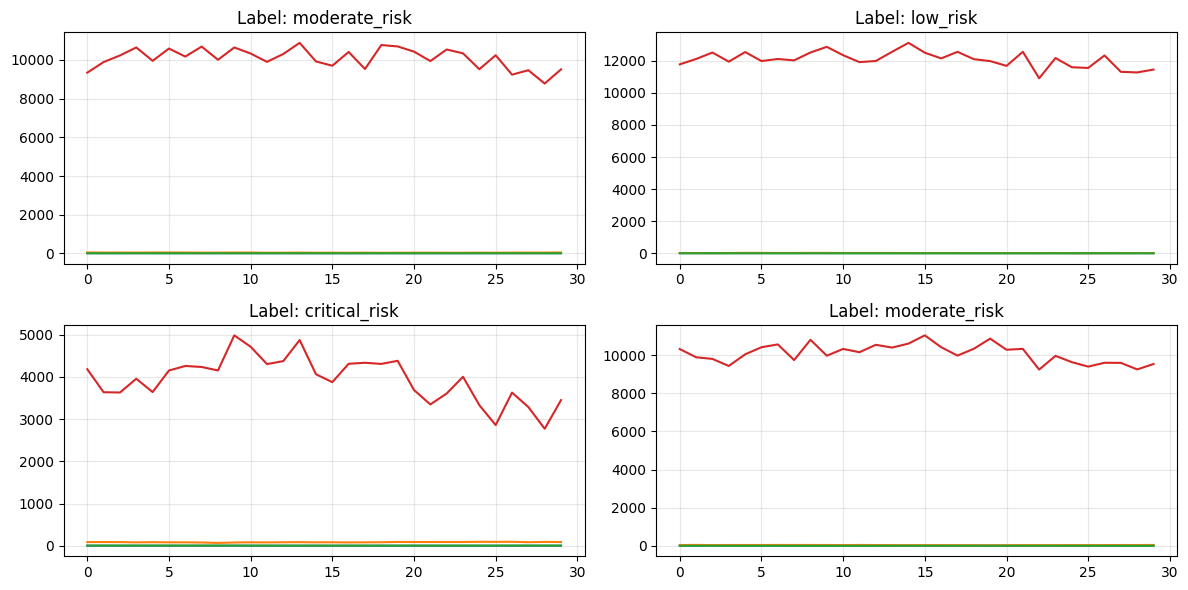

In [20]:
# Looking at a few sample time series
plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.plot(X_ts_train[i].squeeze())
    plt.title(f"Label: {index_to_label[y_ts_train[i]]}")
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# This is a simple 1D CNN for time series classification
def build_timeseries_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(32, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(len(label_to_index), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [22]:
# Training a baseline time series classifier
timeseries_baseline_model = build_timeseries_model(X_ts_train.shape[1:])

history_ts_baseline = timeseries_baseline_model.fit(
    X_ts_train,
    y_ts_train,
    validation_data=(X_ts_val, y_ts_val),
    epochs=20,
    batch_size=16,
    verbose=0
)

ts_baseline_test_loss, ts_baseline_test_acc = timeseries_baseline_model.evaluate(
    X_ts_test,
    y_ts_test,
    verbose=0
)

print("Time Series Baseline Test Accuracy:", round(ts_baseline_test_acc, 4))

Time Series Baseline Test Accuracy: 0.55


In [23]:
# A simple time series augmentation: jittering the sequence with small noise
def augment_timeseries_data(X, noise_std=0.05):
    return X + np.random.normal(0, noise_std, X.shape)

In [24]:
# Creating augmented time series samples
X_ts_train_aug = augment_timeseries_data(X_ts_train, noise_std=0.05)
y_ts_train_aug = y_ts_train.copy()

X_ts_train_combined = np.concatenate([X_ts_train, X_ts_train_aug], axis=0)
y_ts_train_combined = np.concatenate([y_ts_train, y_ts_train_aug], axis=0)

print("Original time series train size:", len(X_ts_train))
print("Combined augmented time series train size:", len(X_ts_train_combined))

Original time series train size: 192
Combined augmented time series train size: 384


In [25]:
# Training the time series model with augmented data
timeseries_aug_model = build_timeseries_model(X_ts_train.shape[1:])

history_ts_aug = timeseries_aug_model.fit(
    X_ts_train_combined,
    y_ts_train_combined,
    validation_data=(X_ts_val, y_ts_val),
    epochs=20,
    batch_size=16,
    verbose=0
)

ts_aug_test_loss, ts_aug_test_acc = timeseries_aug_model.evaluate(
    X_ts_test,
    y_ts_test,
    verbose=0
)

print("Time Series Augmentation Test Accuracy:", round(ts_aug_test_acc, 4))

Time Series Augmentation Test Accuracy: 0.25


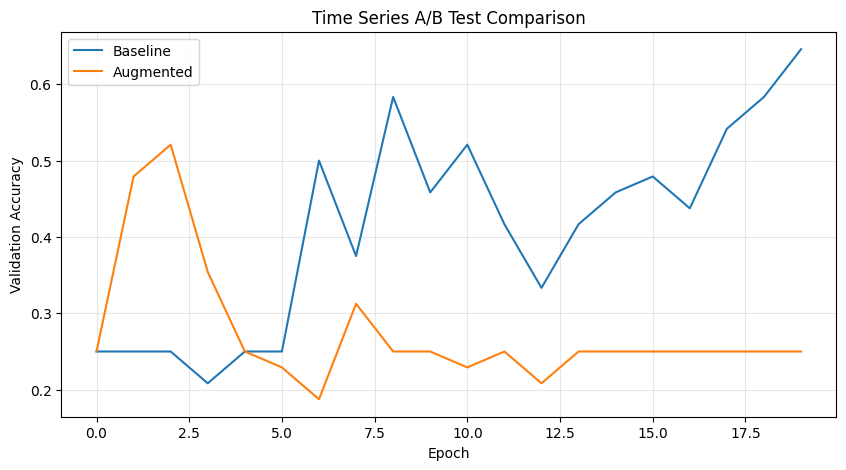

In [26]:
# Comparing baseline vs augmented training for time series data
plt.figure(figsize=(10, 5))
plt.plot(history_ts_baseline.history["val_accuracy"], label="Baseline")
plt.plot(history_ts_aug.history["val_accuracy"], label="Augmented")
plt.title("Time Series A/B Test Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [27]:
# Final summary for both tabular and time series experiments
print("Tabular Results")
print("-" * 40)
print(f"Baseline Model      : {tab_baseline_test_acc:.4f}")
print(f"Augmented Model     : {tab_aug_test_acc:.4f}")

print("\nTime Series Results")
print("-" * 40)
print(f"Baseline Model      : {ts_baseline_test_acc:.4f}")
print(f"Augmented Model     : {ts_aug_test_acc:.4f}")

Tabular Results
----------------------------------------
Baseline Model      : 0.9250
Augmented Model     : 0.9625

Time Series Results
----------------------------------------
Baseline Model      : 0.5500
Augmented Model     : 0.2500


### Final Observation

In this notebook, I explored augmentation for both tabular data and time series data using the synthetic student wellness dataset. For tabular data, I used a simple Gaussian noise strategy to create slightly varied training samples, and for time series I used jitter-based augmentation by adding small noise to the sequences. The goal was to compare a baseline classifier against an augmented-data version in both settings and see whether augmentation helps generalization outside of image and text tasks.